# 背景扣除后 FITS 的 Noise2Noise 自监督去噪

本 Notebook 展示固定帧级切分、lag=2–5 时间配对、残差 DnCNN 训练记录、验证集去噪强度标定、
测试集科学指标。独立伪源盲检评估位于 `notebooks/evaluation/`。
测试集不参与 checkpoint 或 α 选择。

完整重训命令：`python scripts/run_noise2noise.py --stage all --overwrite`。

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits

start = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (start, *start.parents) if (path / "src" / "astr_ir").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("无法定位项目根目录")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

INPUT_ROOT = PROJECT_ROOT / "data" / "processed" / "background"
OUTPUT_ROOT = PROJECT_ROOT / "data" / "processed" / "noise2noise"
FIGURE_ROOT = PROJECT_ROOT / "figures" / "noise2noise_output"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

from astr_ir.noise2noise.visualization import (
    plot_denoising_triplet,
    plot_training_history,
    save_figure,
)

## 1. 固定帧级切分和时间帧对

In [2]:
split = pd.read_csv(
    OUTPUT_ROOT / "manifests" / "split_manifest.csv",
    encoding="utf-8-sig",
    dtype={"sequence": str},
)
pairs = pd.read_csv(
    OUTPUT_ROOT / "manifests" / "pair_manifest.csv",
    encoding="utf-8-sig",
    dtype={"sequence": str},
)
display(split.groupby(["sequence", "split"]).size().rename("frames").to_frame())
display(
    pairs.loc[pairs["usable"]]
    .groupby(["sequence", "split", "lag"])
    .size()
    .rename("pairs")
    .to_frame()
)
assert (pairs["lag"] >= 2).all()
frame_split = split.set_index("frame_id")["split"]
assert all(
    frame_split[row.frame_a] == frame_split[row.frame_b] == row.split
    for row in pairs.itertuples(index=False)
)

frames
sequence split             
90000002 guard            4
         test            16
         train           48
         validation      12
90000003 guard            4
         test            16
         train           48
         validation      12

pairs
sequence split      lag       
90000002 test       2       14
                    3       13
                    4       12
                    5       11
         train      2       46
                    3       45
                    4       44
                    5       43
         validation 2       10
                    3        9
                    4        8
                    5        7
90000003 test       2       14
                    3       13
                    4       12
                    5       11
         train      2       44
                    3       43
                    4       42
                    5       41
         validation 2        9
                    3        8
                    4        7
                    5        6

每序列使用 48/2/12/2/16 的 train/guard/validation/guard/test 时间块。
先切完整帧，再在同一集合内配对，最后在线裁 patch，避免帧或相邻 patch 泄漏。

## 2. 训练历史与最佳 checkpoint

,best checkpoint
epoch,29.000000
train_loss,0.741335
validation_loss,0.707850
learning_rate,0.000050


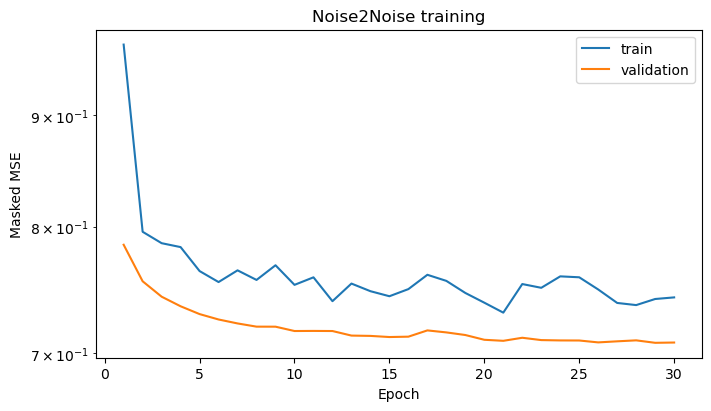

In [3]:
history = pd.read_csv(OUTPUT_ROOT / "checkpoints" / "training_history.csv", encoding="utf-8-sig")
best = history.loc[history["validation_loss"].idxmin()]
display(best.to_frame("best checkpoint"))
fig = plot_training_history(history)
save_figure(fig, FIGURE_ROOT / "01_training_history.png")
plt.show()

## 3. 仅使用高 SNR 验证集标定去噪强度

,selected
strength,0.23
validation_max_abs_photometry_change,0.009914
validation_median_noise_ratio,0.78166
validation_max_noise_ratio,0.78195
passes_photometry_gate,True


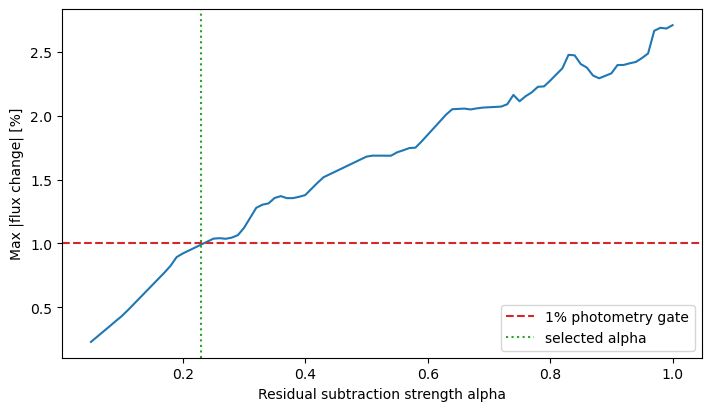

In [4]:
calibration = pd.read_csv(
    OUTPUT_ROOT / "manifests" / "strength_calibration.csv",
    encoding="utf-8-sig",
)
selected = calibration.loc[calibration["passes_photometry_gate"]].sort_values("strength").iloc[-1]
display(selected.to_frame("selected"))
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(calibration["strength"], 100 * calibration["validation_max_abs_photometry_change"])
ax.axhline(1.0, color="tab:red", ls="--", label="1% photometry gate")
ax.axvline(selected["strength"], color="tab:green", ls=":", label="selected alpha")
ax.set(xlabel="Residual subtraction strength alpha", ylabel="Max |flux change| [%]")
ax.legend()
save_figure(fig, FIGURE_ROOT / "02_strength_calibration.png")
plt.show()

## 4. 弱源测试帧的输入、去噪图和预测残差

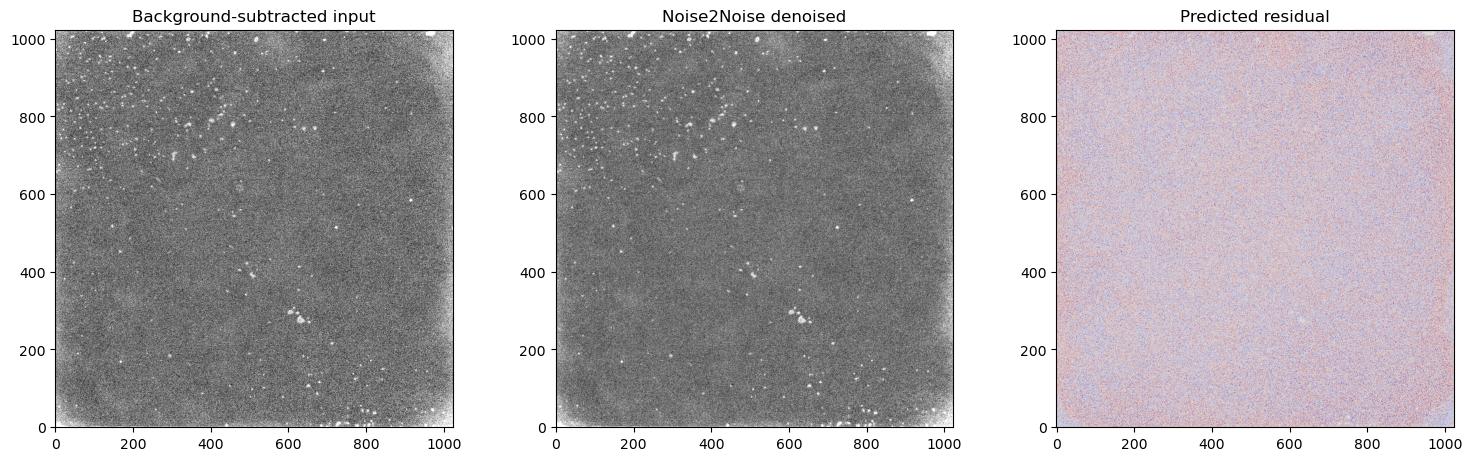

In [5]:
statistics = pd.read_csv(
    OUTPUT_ROOT / "noise2noise_statistics.csv",
    encoding="utf-8-sig",
    dtype={"sequence": str},
)
sample = statistics.loc[
    (statistics["split"] == "test") & (statistics["sequence"] == "90000002")
].iloc[0]
original = np.asarray(
    fits.getdata(INPUT_ROOT / sample["sequence"] / f"background_subtracted_{sample['filename']}"),
    dtype=np.float32,
)
denoised = np.asarray(fits.getdata(OUTPUT_ROOT / sample["denoised_path"]), dtype=np.float32)
fig = plot_denoising_triplet(original, denoised)
save_figure(fig, FIGURE_ROOT / "03_weak_source_triplet.png")
plt.show()

## 5. 冻结测试集科学指标

In [6]:
test = statistics.loc[statistics["split"] == "test"]
weak = test.loc[test["sequence"] == "90000002"]
high = test.loc[test["sequence"] == "90000003"]
metrics = pd.Series({
    "test frames": len(test),
    "median noise ratio": test["noise_ratio"].median(),
    "weak-source median SNR before": weak["aperture_snr_before"].median(),
    "weak-source median SNR after": weak["aperture_snr_after"].median(),
    "weak-source median SNR ratio": weak["aperture_snr_ratio"].median(),
    "high-SNR max |flux change| [%]": 100 * high["photometry_change_fraction"].abs().max(),
    "max float32 equation error": statistics["equation_max_abs_error_float32"].max(),
})
display(metrics.to_frame("value"))

,value
test frames,32.000000
median noise ratio,0.781632
weak-source median SNR before,5.524600
weak-source median SNR after,6.858861
weak-source median SNR ratio,1.258429
high-SNR max |flux change| [%],0.772090
max float32 equation error,0.000000


## 6. 严格产品与科学门验收

In [7]:
completed = subprocess.run(
    [sys.executable, "scripts/validation/validate_noise2noise.py"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=False,
)
print(completed.stdout)
if completed.stderr.strip():
    print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError("Noise2Noise strict validation failed")

Noise2Noise strict validation
  frames/products: 160/320
  float32 equation max error: 0
  test median noise ratio: 0.781632
  weak-source median aperture-SNR ratio: 1.258429
  high-SNR max |flux change|: 0.7721%



## 7. 全项目自动测试

In [8]:
completed = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=False,
)
print(completed.stdout)
if completed.stderr.strip():
    print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError("pytest failed")

.....................................                                    [100%]
37 passed in 6.08s



## 结论

该基线在冻结测试集上降低约 21.8% 相邻像元噪声，弱源孔径 SNR 中位数提高约 25.8%，
同时把高 SNR 最大流量变化控制在 1% 内。通用伪源完备度、纯度和假阳性结果在独立
evaluation Notebook 中展示，避免模型训练模块与科学评估逻辑耦合。